### Examining Data Structure

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('./data/loan_approval_dataset.csv')
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [4]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [5]:
df.columns = df.columns.str.strip()

<small>Column Analysis </small>

In [6]:
df = df.drop(columns=['loan_id'])

In [7]:
categorical_cols = df.drop(columns=['loan_status']).select_dtypes(include=['object']).columns
categorical_cols_list = categorical_cols.tolist()
categorical_cols


Index(['education', 'self_employed'], dtype='object')

In [8]:
numerical_cols = df.drop(columns=categorical_cols.tolist()).columns
numerical_cols = numerical_cols.drop('loan_status')
numerical_cols_list = numerical_cols.tolist()
numerical_cols

Index(['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
       'cibil_score', 'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value'],
      dtype='object')

<small>Dataframe shape and values </small>

In [9]:
df.shape
# 4269 rows and 12 columns

(4269, 12)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   no_of_dependents          4269 non-null   int64 
 1   education                 4269 non-null   object
 2   self_employed             4269 non-null   object
 3   income_annum              4269 non-null   int64 
 4   loan_amount               4269 non-null   int64 
 5   loan_term                 4269 non-null   int64 
 6   cibil_score               4269 non-null   int64 
 7   residential_assets_value  4269 non-null   int64 
 8   commercial_assets_value   4269 non-null   int64 
 9   luxury_assets_value       4269 non-null   int64 
 10  bank_asset_value          4269 non-null   int64 
 11  loan_status               4269 non-null   object
dtypes: int64(9), object(3)
memory usage: 400.3+ KB


<small>Check for nulls </small>

In [11]:
df.isnull().sum()
# no null values

no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

<small>Check for duplicates </small>

In [12]:
df.duplicated().sum() #no duplicates

np.int64(0)

### Analysis

Data shows that the results  for both self-employed and graduated and not remain consistent in distribution


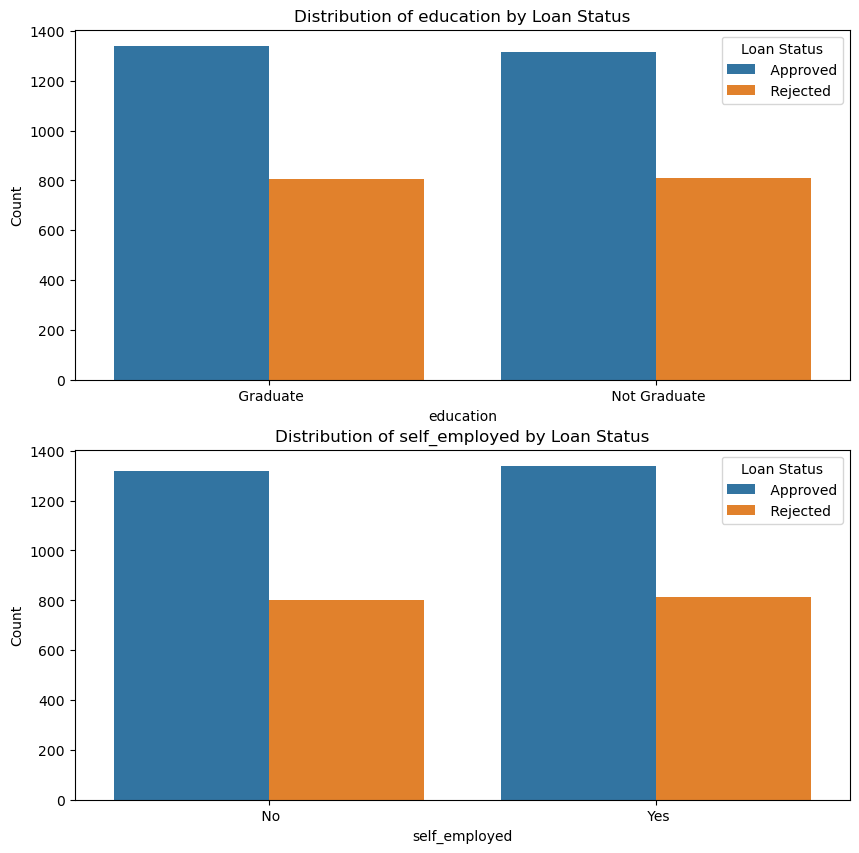

In [13]:
fix, ax = plt.subplots(len(categorical_cols_list), 1, figsize=(10, 5 * len(categorical_cols_list)))
for i, col in enumerate(categorical_cols_list):
    sns.countplot(data=df, x=col, hue='loan_status', ax=ax[i])
    ax[i].set_title(f'Distribution of {col} by Loan Status')
    ax[i].set_xlabel(col)
    ax[i].set_ylabel('Count')
    ax[i].legend(title='Loan Status', loc='upper right')

print("Data shows that the results  for both self-employed and graduated and not remain consistent in distribution")

<small> Discrete Analysis </small>

In [14]:
len(numerical_cols_list)

9

Skewness of no_of_dependents : -0.01797054296784964
no_of_dependents is approximately symmetric.


Skewness of income_annum : -0.012814425096650109
income_annum is approximately symmetric.


Skewness of loan_amount : 0.30872388482299223
loan_amount is approximately symmetric.


Skewness of loan_term : 0.036358907356478495
loan_term is approximately symmetric.


Skewness of cibil_score : -0.009039277330065707
cibil_score is approximately symmetric.


Skewness of residential_assets_value : 0.9784505965115631
residential_assets_value is moderately skewed.


Skewness of commercial_assets_value : 0.9577908874986114
commercial_assets_value is moderately skewed.


Skewness of luxury_assets_value : 0.3222075028955774
luxury_assets_value is approximately symmetric.


Skewness of bank_asset_value : 0.5607250089736816
bank_asset_value is moderately skewed.




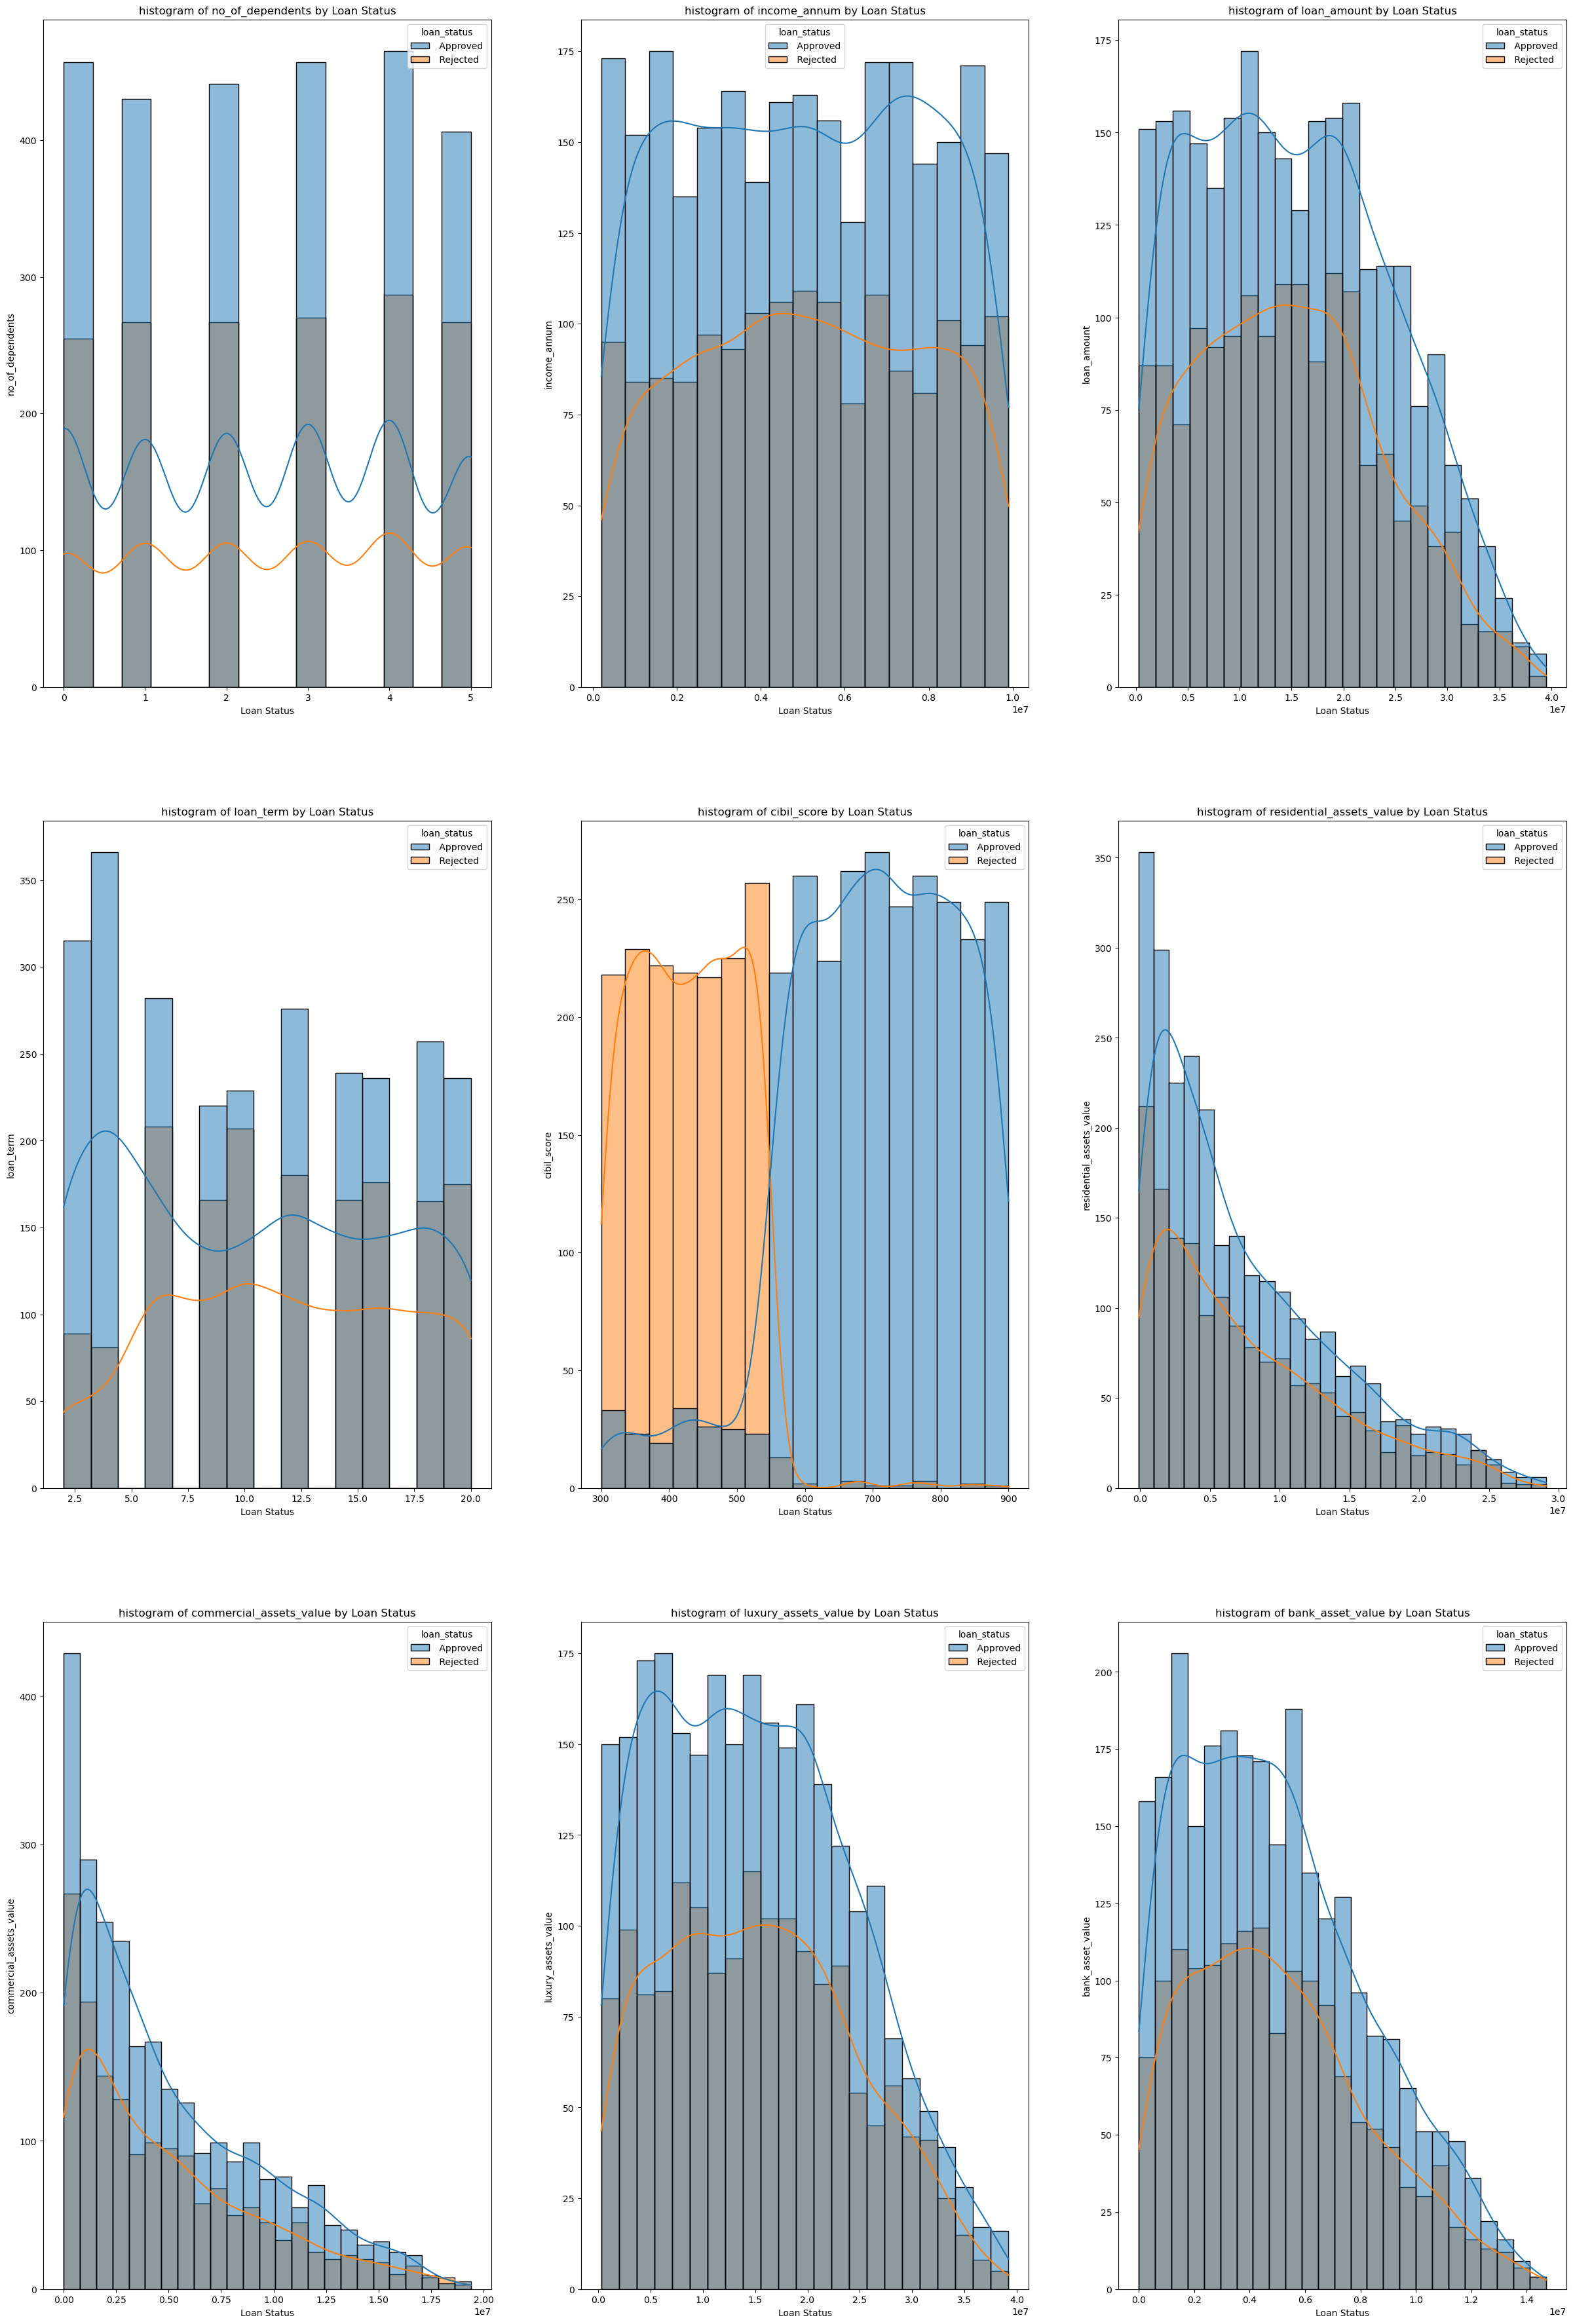

In [15]:
fig, ax = plt.subplots(len(numerical_cols_list)//3, 3, figsize=(10 * 3, 5 * len(numerical_cols_list)))
mod_skew = []
high_skew = []
for i, col in enumerate(numerical_cols_list):
    sns.histplot(data=df, x=col, kde=True, hue='loan_status', ax=ax[i//3, i%3])
    ax[i//3, i%3].set_title(f'histogram of {col} by Loan Status')
    ax[i//3, i%3].set_xlabel('Loan Status')
    ax[i//3, i%3].set_ylabel(col)
    print("Skewness of", col, ":", df[col].skew())
    
    if df[col].skew() > 1 or df[col].skew() < -1:
        print(f"{col} is highly skewed.")
        high_skew.append(col)
    elif df[col].skew() > 0.5 or df[col].skew() < -0.5:
        print(f"{col} is moderately skewed.")
        mod_skew.append(col)
    else:
        print(f"{col} is approximately symmetric.")
    print('\n')

### Encoding

In [16]:
cwt = categorical_cols_list.append('loan_status')
for col in categorical_cols_list:
    df[col] = df[col].str.strip()
    print(f"Unique values in {col}: {df[col].unique()}")
    
    # Graduate is 0, Not_Graduate is 1
    # Not Self_Employed is 0, Self_Employed is 1
    # Approved is 0, Rejected is 1

Unique values in education: ['Graduate' 'Not Graduate']
Unique values in self_employed: ['No' 'Yes']
Unique values in loan_status: ['Approved' 'Rejected']


In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# assign le to each categorical column
for col in categorical_cols_list:
    df[col] = le.fit_transform(df[col])
    



according to the heatmap, the feature with the highest likely correlation (negatively) is the cibil_score(0.7) that is the assumption the lower the cibil_score, the higher the chance of loan rejection


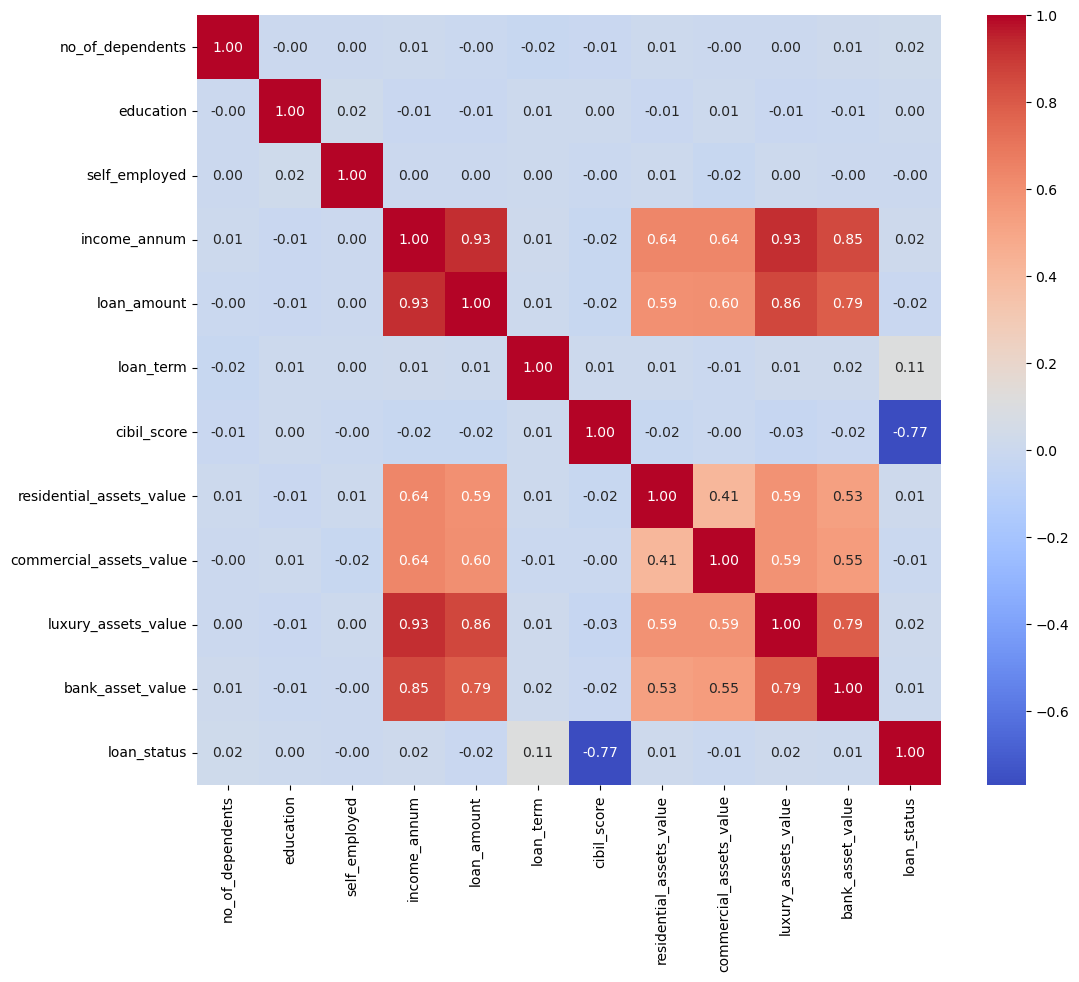

In [18]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
print("according to the heatmap, the feature with the highest likely correlation (negatively) is the cibil_score(0.7) that is the assumption the lower the cibil_score, the higher the chance of loan rejection")

### Removing Outliers, Checking for Erroneous Data

In [19]:
def show_bounds_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print("lower bound", lower_bound)
    print("upper bound", upper_bound)   

In [20]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    clean_data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return clean_data


In [21]:
def check_extremes_from_edges(series, threshold=0.30):
 
    median = series.median()
    min_val = series.min()
    max_val = series.max()
    range_val = max_val - min_val

    lower_bound = median - threshold * range_val
    upper_bound = median + threshold * range_val

    return {
        "min_value": min_val,
        "min_class": "Lower Extreme" if min_val < lower_bound else "Normal",
        "max_value": max_val,
        "max_class": "Upper Extreme" if max_val > upper_bound else "Normal",
        "median": median,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound
    }


In [22]:

def remove_outliers_threshold(df, column, threshold=0.25):
  
    median = df[column].median()
    min_val = df[column].min()
    max_val = df[column].max()
    range_val = max_val - min_val

    lower_bound = median - threshold * range_val
    upper_bound = median + threshold * range_val

    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]


<small>Even if we have little correlation with the residential, commericial and bank asset value we need to check them, because there seems to be an effect with getting a loan approved - histogram skewed to the right means the mean is greater than the median. Correlation wise, Cibil Status seems to be a feature that determines the target the most </small>

Cibil Score and Loan Status (-0.7 correlation)

Take note that 0 in the LE is actually approved and 1 is not approved, shows some outliers but generally the lower the cibil score, the higher the chance of loan rejection


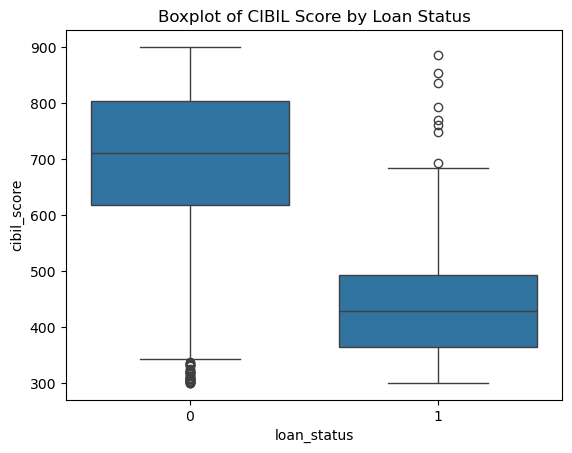

In [23]:
sns.boxplot(data=df, x='loan_status', y='cibil_score')
plt.title('Boxplot of CIBIL Score by Loan Status')
print("Take note that 0 in the LE is actually approved and 1 is not approved, shows some outliers but generally the lower the cibil score, the higher the chance of loan rejection")

In [24]:
show_bounds_iqr(df, 'cibil_score')
df = remove_outliers_iqr(df, 'cibil_score')

lower bound 10.5
upper bound 1190.5


In [25]:
check_extremes_from_edges(df['cibil_score'], threshold=0.25)
# reasonable outliers

{'min_value': 300,
 'min_class': 'Lower Extreme',
 'max_value': 900,
 'max_class': 'Upper Extreme',
 'median': 600.0,
 'lower_bound': 450.0,
 'upper_bound': 750.0}

In [26]:
# check upper bound with loan_status not approved
df[(df['cibil_score'] > 750) & (df['loan_status'] == 1)]

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
236,3,0,1,900000,3500000,4,770,700000,0,2000000,600000,1
559,2,0,1,200000,500000,6,885,-100000,0,300000,200000,1
911,0,0,1,1300000,4800000,4,835,500000,100000,3300000,800000,1
3213,1,1,1,4300000,16300000,14,792,400000,400000,10200000,4000000,1
3527,0,0,0,1800000,6900000,10,853,900000,400000,3700000,1700000,1
4099,3,0,0,8700000,31100000,16,760,400000,1800000,19300000,4800000,1


In [27]:
# check lower bound with loan_status approved
df[(df['cibil_score'] < 450) & (df['loan_status'] == 0)]

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
71,5,0,1,5300000,18600000,4,386,2700000,9700000,11900000,4200000,0
95,5,0,0,300000,1100000,2,300,100000,500000,700000,400000,0
152,1,0,1,6500000,20600000,2,306,15900000,1900000,18100000,3200000,0
169,0,1,1,4800000,17500000,2,371,11700000,6800000,18700000,3500000,0
260,4,1,0,2700000,8100000,4,325,5000000,800000,9900000,3400000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4075,4,1,1,2600000,8500000,4,392,5500000,100000,8800000,2900000,0
4081,2,1,1,4400000,16800000,4,307,12800000,7200000,9700000,5800000,0
4139,3,0,0,5600000,20300000,4,330,16100000,5100000,15300000,4200000,0
4161,5,1,0,1100000,4000000,2,362,1800000,1300000,3500000,1100000,0


Residential and Loan Status (Moderately Skewed to the Right)

Take note that 0 in the LE is actually approved and 1 is not approved, shows outliers in both sides, that is residential assets value have upper outliers


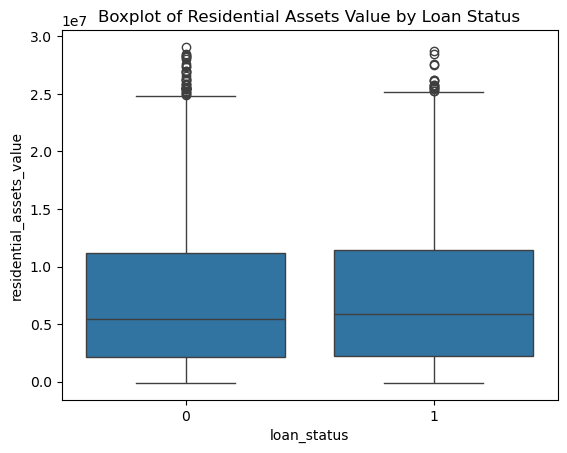

In [28]:
sns.boxplot(data=df, x='loan_status', y='residential_assets_value')
plt.title('Boxplot of Residential Assets Value by Loan Status')
print("Take note that 0 in the LE is actually approved and 1 is not approved, shows outliers in both sides, that is residential assets value have upper outliers")

In [29]:
show_bounds_iqr(df, 'residential_assets_value')
# shows negative lower bound which is not possible
df = df[df['residential_assets_value'] >= 0]


lower bound -11450000.0
upper bound 24950000.0


In [30]:
check_extremes_from_edges(df['residential_assets_value'], threshold=0.25)

{'min_value': 0,
 'min_class': 'Normal',
 'max_value': 29100000,
 'max_class': 'Upper Extreme',
 'median': 5700000.0,
 'lower_bound': -1575000.0,
 'upper_bound': 12975000.0}

Bank and Loan Status (Moderately Skewed to the Right)

Take note that 0 in the LE is actually approved and 1 is not approved, shows outliers in both sides, that is bank assets value have upper outliers


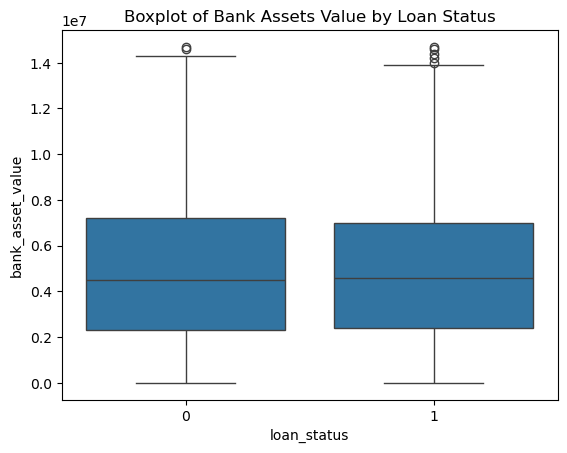

In [31]:
sns.boxplot(data=df, x='loan_status', y='bank_asset_value')
plt.title('Boxplot of Bank Assets Value by Loan Status')
print("Take note that 0 in the LE is actually approved and 1 is not approved, shows outliers in both sides, that is bank assets value have upper outliers")

In [32]:
show_bounds_iqr(df, 'bank_asset_value')
# shows negative lower bound which is not possible
df = df[df['bank_asset_value'] >= 0]

lower bound -4650000.0
upper bound 14150000.0


In [33]:
check_extremes_from_edges(df['bank_asset_value'], threshold=0.25)

{'min_value': 0,
 'min_class': 'Lower Extreme',
 'max_value': 14700000,
 'max_class': 'Upper Extreme',
 'median': 4600000.0,
 'lower_bound': 925000.0,
 'upper_bound': 8275000.0}

Commercial and Loan Status (Moderately Skewed to the Right)

Take note that 0 in the LE is actually approved and 1 is not approved, shows outliers in both sides, that is commercial assets value have upper outliers


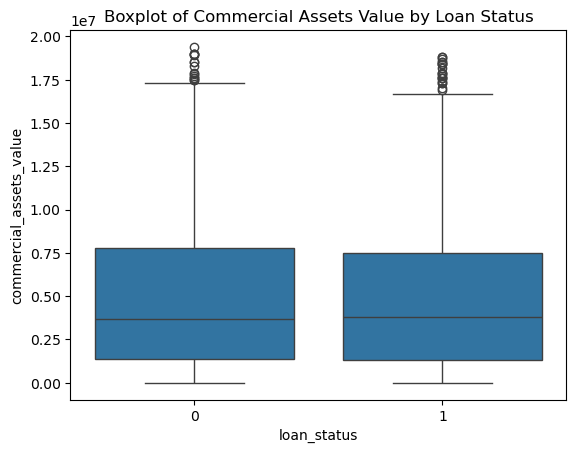

In [34]:
sns.boxplot(data=df, x='loan_status', y='commercial_assets_value')
plt.title('Boxplot of Commercial Assets Value by Loan Status')
print("Take note that 0 in the LE is actually approved and 1 is not approved, shows outliers in both sides, that is commercial assets value have upper outliers")

In [35]:
show_bounds_iqr(df, 'commercial_assets_value')
# shows negative lower bound which is not possible
df = df[df['commercial_assets_value'] >= 0]

lower bound -8300000.0
upper bound 17300000.0


In [36]:
check_extremes_from_edges(df['commercial_assets_value'], threshold=0.25)

{'min_value': 0,
 'min_class': 'Normal',
 'max_value': 19400000,
 'max_class': 'Upper Extreme',
 'median': 3700000.0,
 'lower_bound': -1150000.0,
 'upper_bound': 8550000.0}

In [37]:
for cols in numerical_cols_list:
   print("Extremes check for", cols)
   print(check_extremes_from_edges(df[cols], threshold=0.25))
   print('\n')

Extremes check for no_of_dependents
{'min_value': 0, 'min_class': 'Lower Extreme', 'max_value': 5, 'max_class': 'Upper Extreme', 'median': 3.0, 'lower_bound': 1.75, 'upper_bound': 4.25}


Extremes check for income_annum
{'min_value': 200000, 'min_class': 'Lower Extreme', 'max_value': 9900000, 'max_class': 'Upper Extreme', 'median': 5100000.0, 'lower_bound': 2675000.0, 'upper_bound': 7525000.0}


Extremes check for loan_amount
{'min_value': 300000, 'min_class': 'Lower Extreme', 'max_value': 39500000, 'max_class': 'Upper Extreme', 'median': 14600000.0, 'lower_bound': 4800000.0, 'upper_bound': 24400000.0}


Extremes check for loan_term
{'min_value': 2, 'min_class': 'Lower Extreme', 'max_value': 20, 'max_class': 'Upper Extreme', 'median': 10.0, 'lower_bound': 5.5, 'upper_bound': 14.5}


Extremes check for cibil_score
{'min_value': 300, 'min_class': 'Lower Extreme', 'max_value': 900, 'max_class': 'Upper Extreme', 'median': 600.0, 'lower_bound': 450.0, 'upper_bound': 750.0}


Extremes check 

### Feature Engineering

In [38]:
# enforce ordinal encoding 
# 0 - 2 good rating 1 - fair rating 0 - poor rating
df['cibil_rating'] = df['cibil_score'].apply(lambda x: 2 if x >= 750 else( 0 if x < 650 else 1))

# gets the overall asset value by summing up all asset values
df['overall_asset_value'] = df['residential_assets_value'] + df['commercial_assets_value'] + df['bank_asset_value']

In [39]:
df_feat = df.copy()
print('take not the approved is 0 and not approved is 1 in loan_status')
df_feat

take not the approved is 0 and not approved is 1 in loan_status


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,cibil_rating,overall_asset_value
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0,2,28000000
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1,0,8200000
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1,0,24400000
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1,0,29400000
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1,0,25600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,0,1,1000000,2300000,12,317,2800000,500000,3300000,800000,1,0,4100000
4265,0,1,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,0,0,9000000
4266,2,1,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,1,0,20900000
4267,1,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,0,2,14700000


### Splitting and Sampling

In [40]:
X = df_feat.drop(columns=['loan_status'])
y = df_feat['loan_status']

Shows a greater number of approved loans compared to rejected loans, use techniques to handle class imbalance if necessary


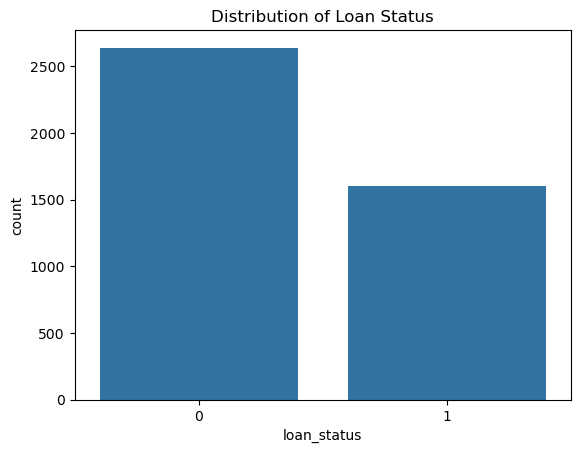

In [41]:
sns.countplot(data=df_feat, x='loan_status')
plt.title('Distribution of Loan Status')
print('Shows a greater number of approved loans compared to rejected loans, use techniques to handle class imbalance if necessary')

Splitting

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Sampling

In [44]:
from imblearn.over_sampling import  SMOTE
smote = SMOTE(random_state=42)

In [45]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

Text(0.5, 1.0, 'Distribution of Loan Status')

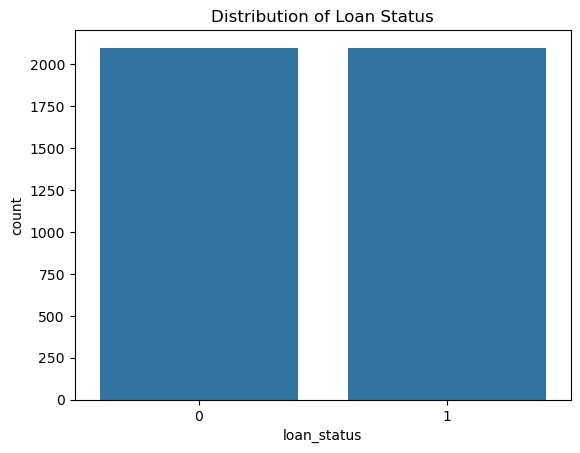

In [46]:
sns.countplot(x = y_train_smote)
plt.title('Distribution of Loan Status')    

### Scaling

In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [48]:
print("Old Scale: ")
print(np.min(X_train_smote)," <-> " ,np.max(X_train_smote))

Old Scale: 
0  <->  57500000


In [49]:
# only apply scaling to X values
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [50]:
print("New Scale:")
print(np.min(X_train_scaled)," <-> " ,np.max(X_train_scaled))

New Scale:
-1.7499017106001005  <->  3.475291951481742


### Classifiers

In [51]:
from sklearn.metrics import classification_report, accuracy_score

Scaled

Logistic Regression

In [52]:
from sklearn import linear_model
log_reg = linear_model.LogisticRegression()
log_reg.fit(X_train_scaled, y_train_smote)

LogisticRegression()

In [53]:
log_reg_pred = log_reg.predict(X_test_scaled)
log_reg_accuracy = accuracy_score(y_test, log_reg_pred)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, log_reg_pred))
print("Accuracy:", log_reg_accuracy)

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       543
           1       0.88      0.94      0.91       306

    accuracy                           0.93       849
   macro avg       0.92      0.93      0.93       849
weighted avg       0.93      0.93      0.93       849

Accuracy: 0.9328621908127208


KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train_scaled, y_train_smote)
knn_pred = knn.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, knn_pred)

print("K-Nearest Neighbors Classification Report:")
print(classification_report(y_test, knn_pred))
print("Accuracy:", knn_accuracy)

K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       543
           1       0.82      0.88      0.85       306

    accuracy                           0.89       849
   macro avg       0.88      0.89      0.88       849
weighted avg       0.89      0.89      0.89       849

Accuracy: 0.8881036513545347


SVC

In [61]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(X_train_scaled, y_train_smote)
svc_pred = svc.predict(X_test_scaled)
svc_accuracy = accuracy_score(y_test, svc_pred)

print("SVC Classification Report:")
print(classification_report(y_test, svc_pred))
print("Accuracy:", svc_accuracy)

SVC Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       543
           1       0.91      0.97      0.94       306

    accuracy                           0.96       849
   macro avg       0.95      0.96      0.95       849
weighted avg       0.96      0.96      0.96       849

Accuracy: 0.9552414605418139


Non Scaled

Decision Tree

In [63]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train_smote, y_train_smote)
dtc_pred = dtc.predict(X_test)

dtc_accuracy = accuracy_score(y_test, dtc_pred)
print("Decision Tree Classification Report:")
print(classification_report(y_test, dtc_pred))
print("Accuracy:", dtc_accuracy)

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       543
           1       0.96      0.99      0.98       306

    accuracy                           0.98       849
   macro avg       0.98      0.98      0.98       849
weighted avg       0.98      0.98      0.98       849

Accuracy: 0.9823321554770318


Random Forest

In [64]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train_smote, y_train_smote)

rfc_pred = rfc.predict(X_test)
rfc_accuracy = accuracy_score(y_test, rfc_pred)
print("Random Forest Classification Report:")
print(classification_report(y_test, rfc_pred))
print("Accuracy:", rfc_accuracy)

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       543
           1       0.95      0.99      0.97       306

    accuracy                           0.98       849
   macro avg       0.97      0.98      0.98       849
weighted avg       0.98      0.98      0.98       849

Accuracy: 0.9776207302709069


Naive Bayes

In [65]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train_smote, y_train_smote)
nb_pred = nb.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Classification Report:")
print(classification_report(y_test, nb_pred))
print("Accuracy:", nb_accuracy)

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.79      0.85       543
           1       0.70      0.86      0.77       306

    accuracy                           0.82       849
   macro avg       0.80      0.82      0.81       849
weighted avg       0.83      0.82      0.82       849

Accuracy: 0.8150765606595995


From the comparison, it appears that Decision Tree and Random Forest performed the best while Naive Bayes performed the worst.


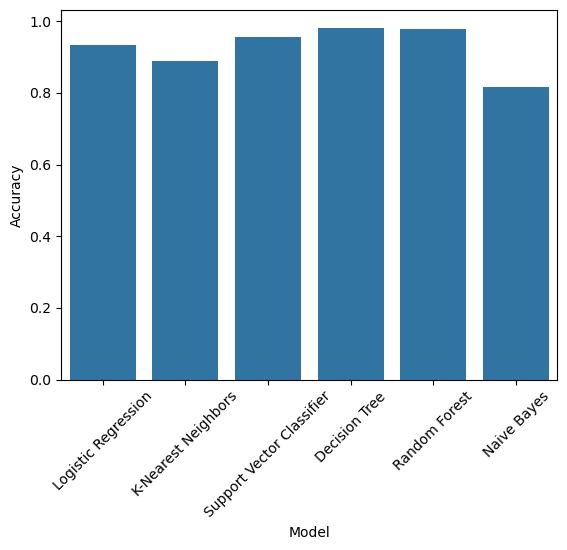

In [67]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'K-Nearest Neighbors', 'Support Vector Classifier', 'Decision Tree', 'Random Forest', 'Naive Bayes'],
    'Accuracy': [log_reg_accuracy, knn_accuracy, svc_accuracy, dtc_accuracy, rfc_accuracy, nb_accuracy]
})

sns.barplot(data=comparison, x='Model', y='Accuracy')
plt.xticks(rotation=45)
print('From the comparison, it appears that Decision Tree and Random Forest performed the best while Naive Bayes performed the worst.')